In [2]:
print("""
=========================================================
CERN Electron Collision Sensor Data Analysis

Objective:
1. Predict Invariant Mass (M)
2. Sensor Explainability
3. Sensor Purging
4. Redundant Sensor Prediction

Dataset:
CERN Dielectron Dataset
=========================================================
""")


CERN Electron Collision Sensor Data Analysis

Objective:
1. Predict Invariant Mass (M)
2. Sensor Explainability
3. Sensor Purging
4. Redundant Sensor Prediction

Dataset:
CERN Dielectron Dataset



In [ ]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns while printing dataframe
pd.set_option("display.max_columns", None)

# Display only 3 decimal places
pd.set_option("display.float_format", "{:.3f}".format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [6]:
# ===============================
# Read Dataset
# ===============================

df = pd.read_csv("../data/raw/dielectron.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [7]:
# Display first five rows

df.head()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,-1,8.948
1,147115,366704169,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,-1,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893
2,147115,367112316,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388
3,147115,366952149,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,-1,3.729
4,147115,366523212,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,-1,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,-1,2.747


In [8]:
# Number of rows and columns

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 100000
Columns : 19


In [9]:
# Display all column names

df.columns.tolist()

['Run',
 'Event',
 'E1',
 'px1 ',
 'py1',
 'pz1',
 'pt1',
 'eta1',
 'phi1',
 'Q1',
 'E2',
 'px2',
 'py2',
 'pz2',
 'pt2',
 'eta2',
 'phi2',
 'Q2',
 'M']

In [10]:
# Information about dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   E1      100000 non-null  float64
 3   px1     100000 non-null  float64
 4   py1     100000 non-null  float64
 5   pz1     100000 non-null  float64
 6   pt1     100000 non-null  float64
 7   eta1    100000 non-null  float64
 8   phi1    100000 non-null  float64
 9   Q1      100000 non-null  int64  
 10  E2      100000 non-null  float64
 11  px2     100000 non-null  float64
 12  py2     100000 non-null  float64
 13  pz2     100000 non-null  float64
 14  pt2     100000 non-null  float64
 15  eta2    100000 non-null  float64
 16  phi2    100000 non-null  float64
 17  Q2      100000 non-null  int64  
 18  M       99915 non-null   float64
dtypes: float64(15), int64(4)
memory usage: 14.5 MB


In [11]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Run,100000.000,147935.327,920.306,146511.000,147114.000,147929.000,149011.000,149182.000
Event,100000.000,495721181.098,403770324.843,6414.000,202396962.750,390275920.500,633889097.500,1791247487.000
E1,100000.000,36.436,41.216,0.378,8.459,21.717,50.003,850.602
px1,100000.000,0.136,13.405,-250.587,-5.234,0.141,5.715,134.539
py1,100000.000,0.182,13.470,-126.079,-5.276,0.099,5.648,147.467
pz1,100000.000,-1.508,51.604,-840.987,-15.860,-0.313,13.213,760.096
pt1,100000.000,14.412,12.389,0.220,3.771,12.968,20.019,265.578
eta1,100000.000,-0.064,1.462,-4.165,-1.284,-0.061,1.144,2.623
phi1,100000.000,0.022,1.800,-3.142,-1.527,0.034,1.562,3.141
Q1,100000.000,-0.005,1.000,-1.000,-1.000,-1.000,1.000,1.000


In [12]:
# Check missing values

missing = df.isnull().sum()

missing

Run       0
Event     0
E1        0
px1       0
py1       0
pz1       0
pt1       0
eta1      0
phi1      0
Q1        0
E2        0
px2       0
py2       0
pz2       0
pt2       0
eta2      0
phi2      0
Q2        0
M        85
dtype: int64

In [13]:
# Count duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 23


In [14]:
# Number of unique values in every column

df.nunique()

Run         13
Event    99976
E1       95669
px1      97213
py1      97153
pz1      98152
pt1      91788
eta1     94037
phi1     94641
Q1           2
E2       95425
px2      97392
py2      97410
pz2      97924
pt2      92789
eta2     89752
phi2     94494
Q2           2
M        93244
dtype: int64

In [15]:
# Target Variable

target = "M"

print(df[target].describe())

count   99915.000
mean       30.020
std        25.256
min         2.000
25%        12.445
50%        21.283
75%        39.025
max       109.999
Name: M, dtype: float64


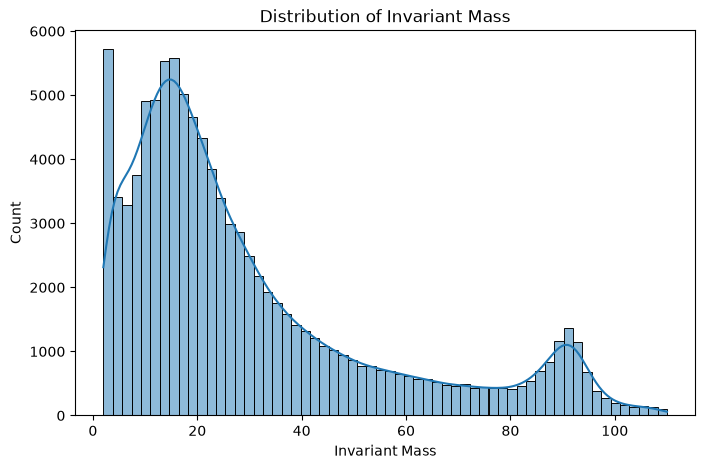

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["M"], bins=60, kde=True)

plt.title("Distribution of Invariant Mass")

plt.xlabel("Invariant Mass")

plt.ylabel("Count")

plt.show()

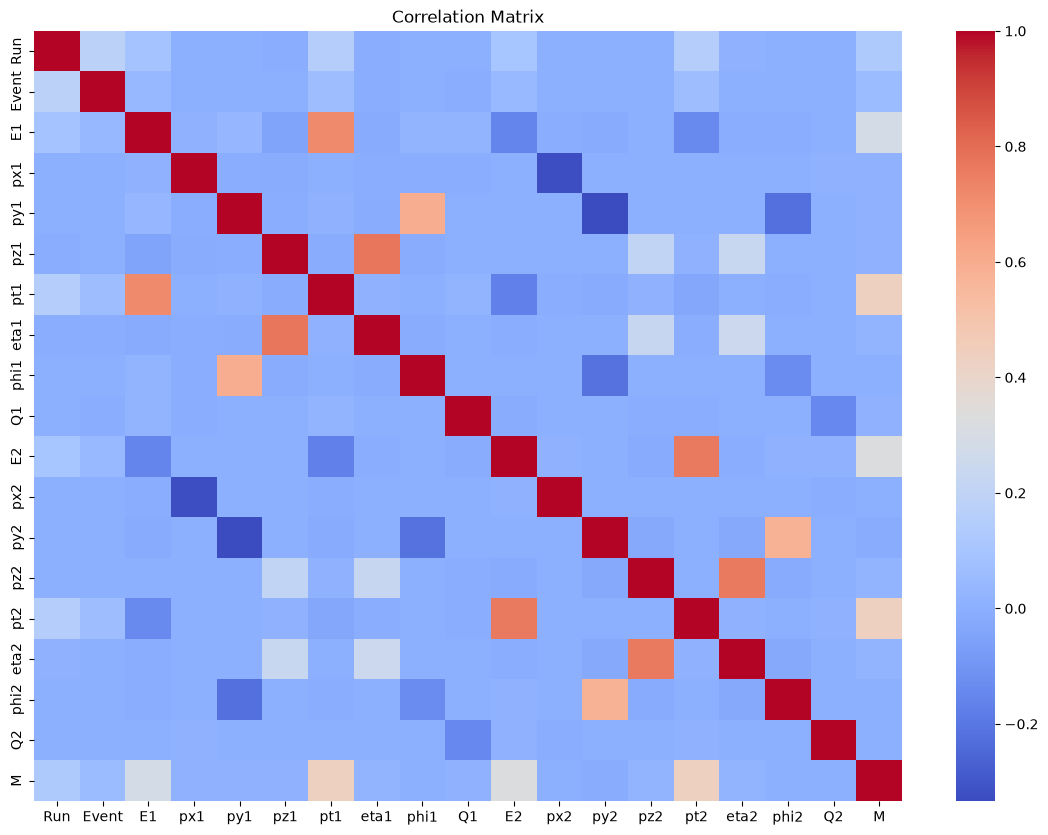

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(corr,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [18]:
print("="*50)

print("Dataset Shape :", df.shape)

print()

print("Missing Values")

print(df.isnull().sum())

print()

print("Duplicate Rows :", duplicates)

print("="*50)

Dataset Shape : (100000, 19)

Missing Values
Run       0
Event     0
E1        0
px1       0
py1       0
pz1       0
pt1       0
eta1      0
phi1      0
Q1        0
E2        0
px2       0
py2       0
pz2       0
pt2       0
eta2      0
phi2      0
Q2        0
M        85
dtype: int64

Duplicate Rows : 23
